In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [2]:
from importlib import reload
import functions_kde_js
import clustering_functions
reload(functions_kde_js)
reload(clustering_functions)
import seed_fix
reload(seed_fix)
from seed_fix import set_seeds

from functions_kde_js import ( run_md_sensitivity_analysis, run_cluster_threshold_sensitivity)
from my_imports import  plot1_params
from clustering_functions import run_dynamic_clustering
set_seeds()
plot1_params()

In [ ]:
results = run_md_sensitivity_analysis(
    global_start_date="07-2018",
    global_end_date="04-2019",
    plot=True,
    zone="America/Los_Angeles"
)

In [ ]:
state = run_dynamic_clustering(global_start_date="07-2018",
                               global_end_date="04-2019",
                               js_lim_month=0.26,
                               js_lim_cluster=0.36,
                               zone="America/Los_Angeles")

In [5]:
cluster_objects_pool = state["cluster_objects_pool"]
monthly_kde = state["monthly_kde"]
monthly_kde_mD = state["monthly_kde_mD"]
cluster_kdes = state["cluster_kdes"]

stream_order = state["stream_order"]
kmeans_objects_dict = state["kmeans_objects_dict"]
similarity_matrix = state["similarity_matrix"]

js_per_feature_mat = state["js_per_feature_mat"]
js_mat_time_order = state["js_mat_time_order"]
js_md_per_month = state["js_md_per_month"]

all_monthly_kde = state["all_monthly_kde"]
all_clusters_kde = state["all_clusters_kde"]
scaler = state["scaler"]

In [ ]:
results = run_cluster_threshold_sensitivity(
    all_clusters_kde=all_clusters_kde,
    plot=True
)

In [7]:
import plot_function_results
reload(plot_function_results)
from plot_function_results import (drift_plot_v2, styled_step_plot_with_dots, rename_cluster_keys,
                                   compute_relative_popularity, plot_cluster_relative_popularity, plot_feature_kde_changes, apply_new_names, plot_clusters_delay, plot_average_load_and_delay_separate)

In [8]:
plot1_params(fsize1_=12.5, dpi1_=200)

In [9]:
global_start_date="07-2018"
global_end_date="04-2019"

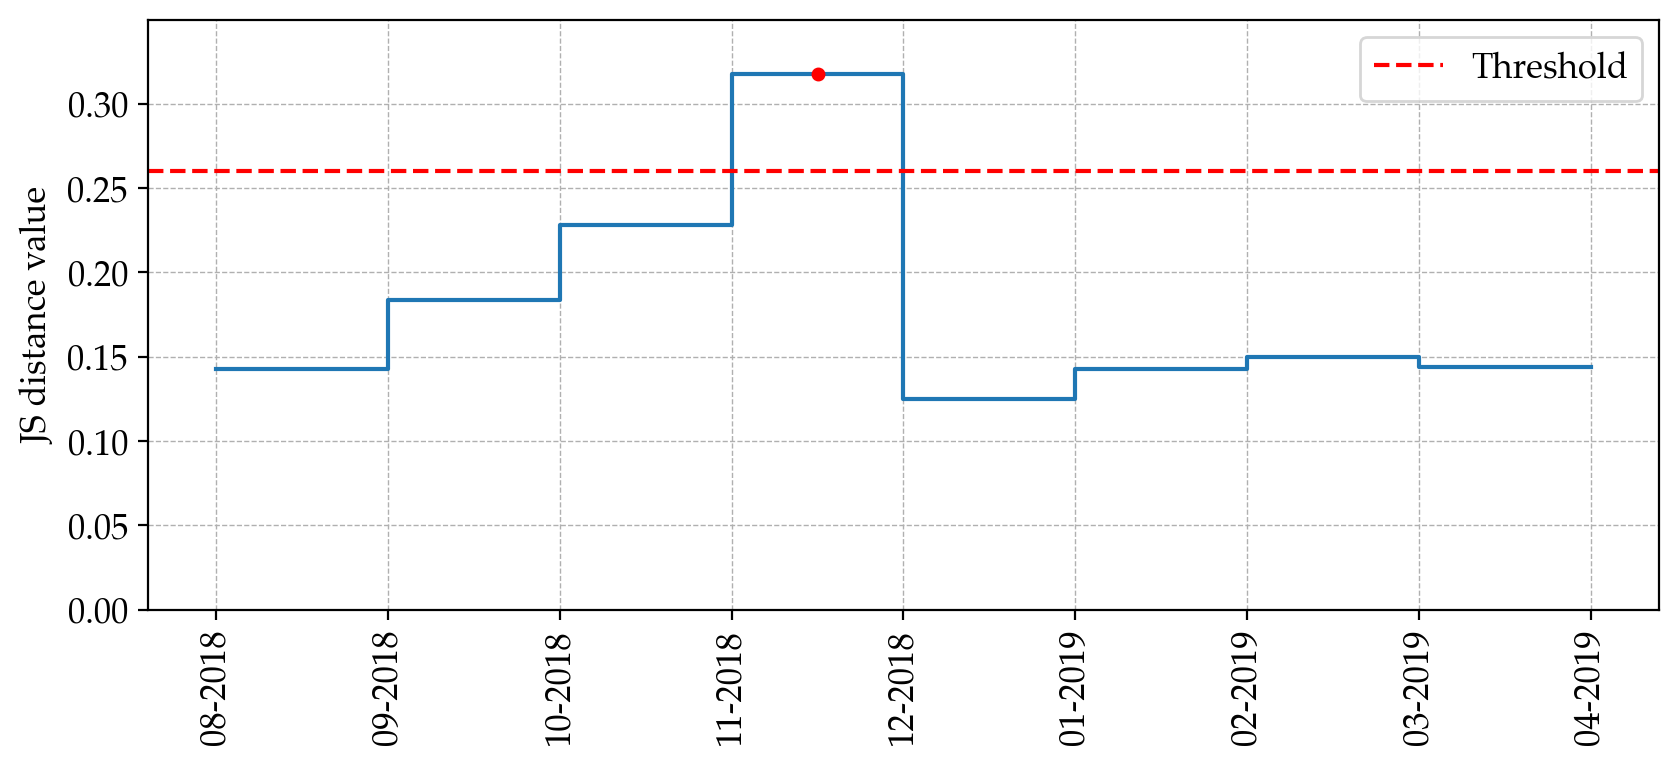

In [10]:
styled_step_plot_with_dots(js_md_per_month, threshold=0.26)

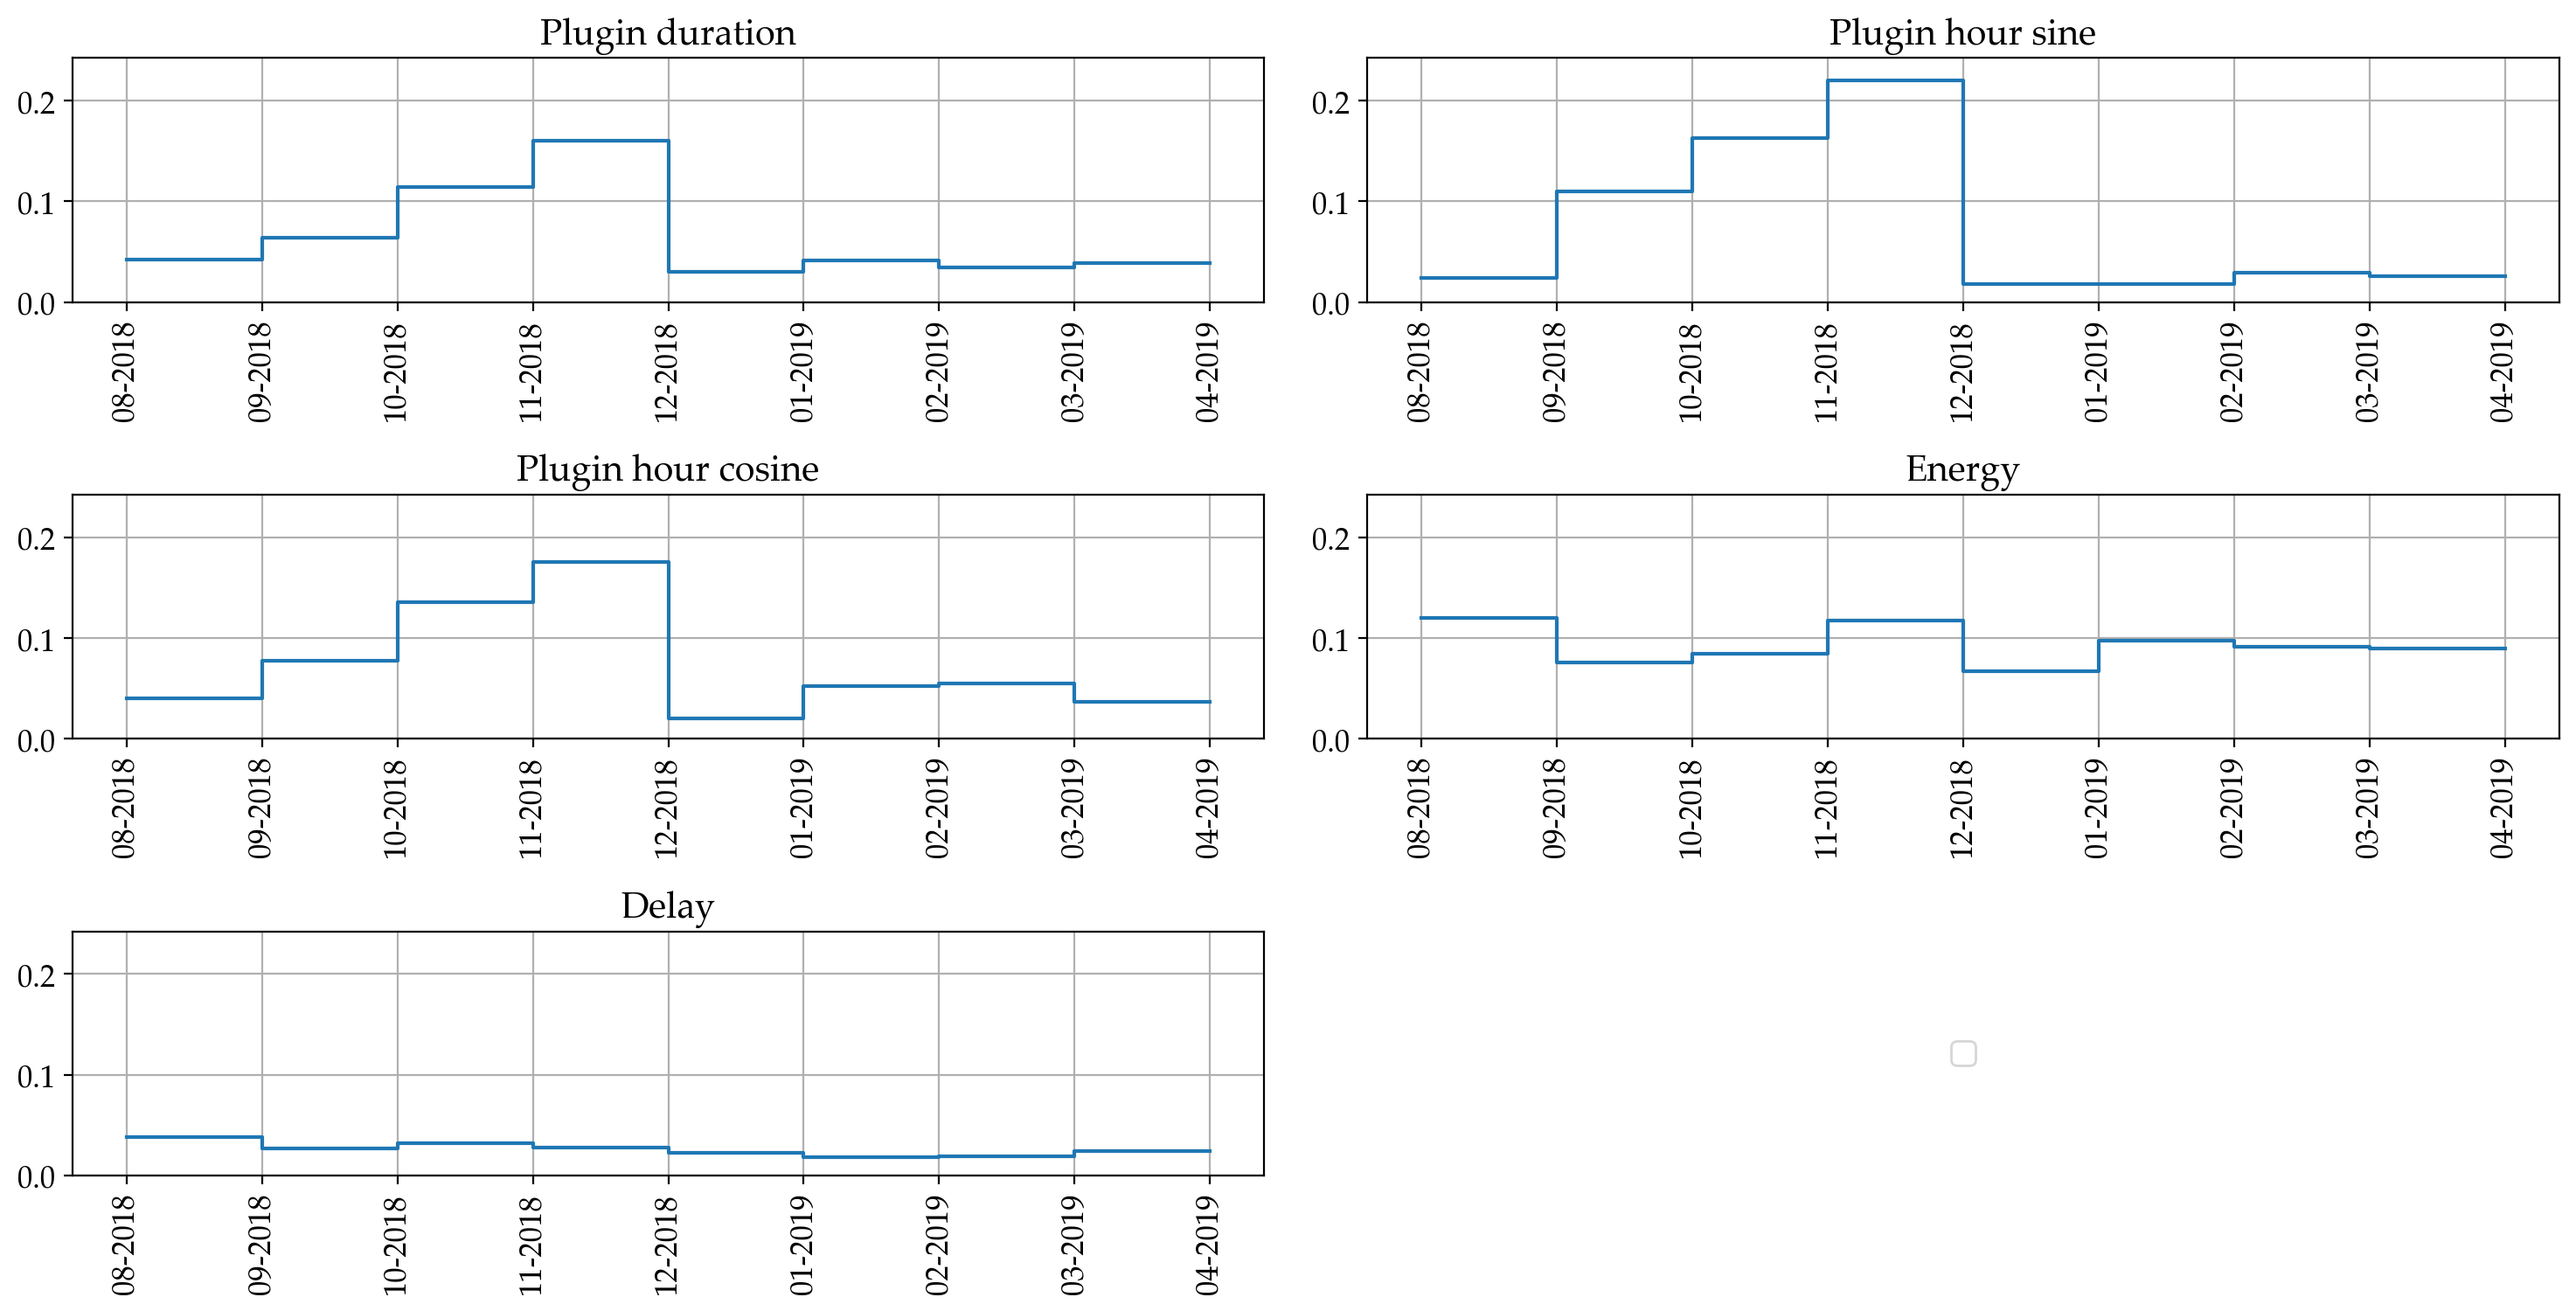

In [11]:
drift_plot_v2(js_per_feature_mat, js_mat_time_order, global_end_date)

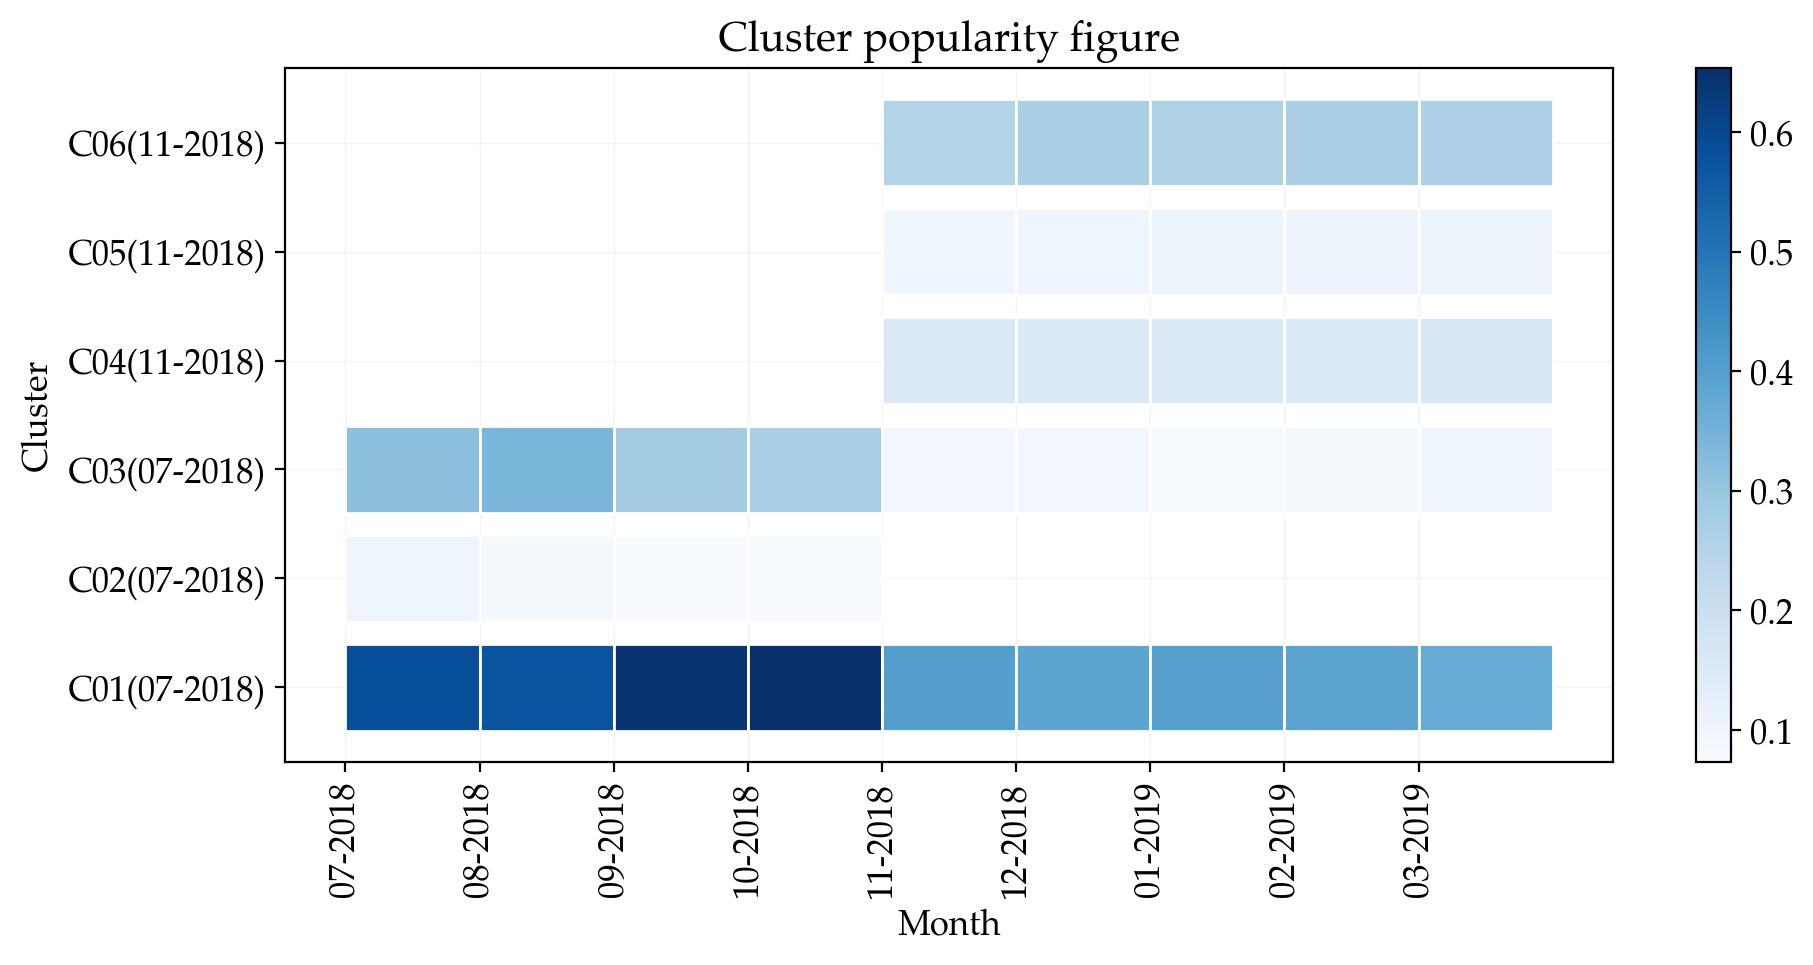

In [12]:
re_ordered_clusters, old_new_tags = rename_cluster_keys(cluster_kdes)
relative_popularity_dict = compute_relative_popularity(re_ordered_clusters)
fig, ax, corrected_data, key_old_new = plot_cluster_relative_popularity(
    relative_popularity_dict
)

In [13]:
feature_names = ["Plugin duration", 'Plugin hour sine', "Plugin hour cosine", 'Energy', 'Delay']

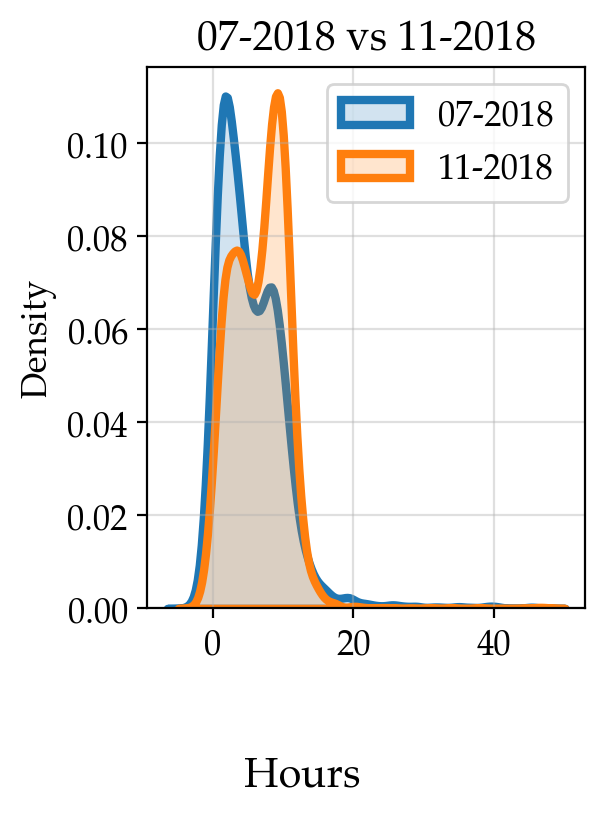

In [14]:
plot_feature_kde_changes(
    feature_name="Plugin duration",
    feature_names=feature_names,
    js_per_feature_mat=js_per_feature_mat,
    js_mat_time_order=js_mat_time_order,
    all_monthly_kde=all_monthly_kde,
    scaler=state["scaler"],
    months_to_compare=[
        "07-2018",
        "11-2018",

    ],
)

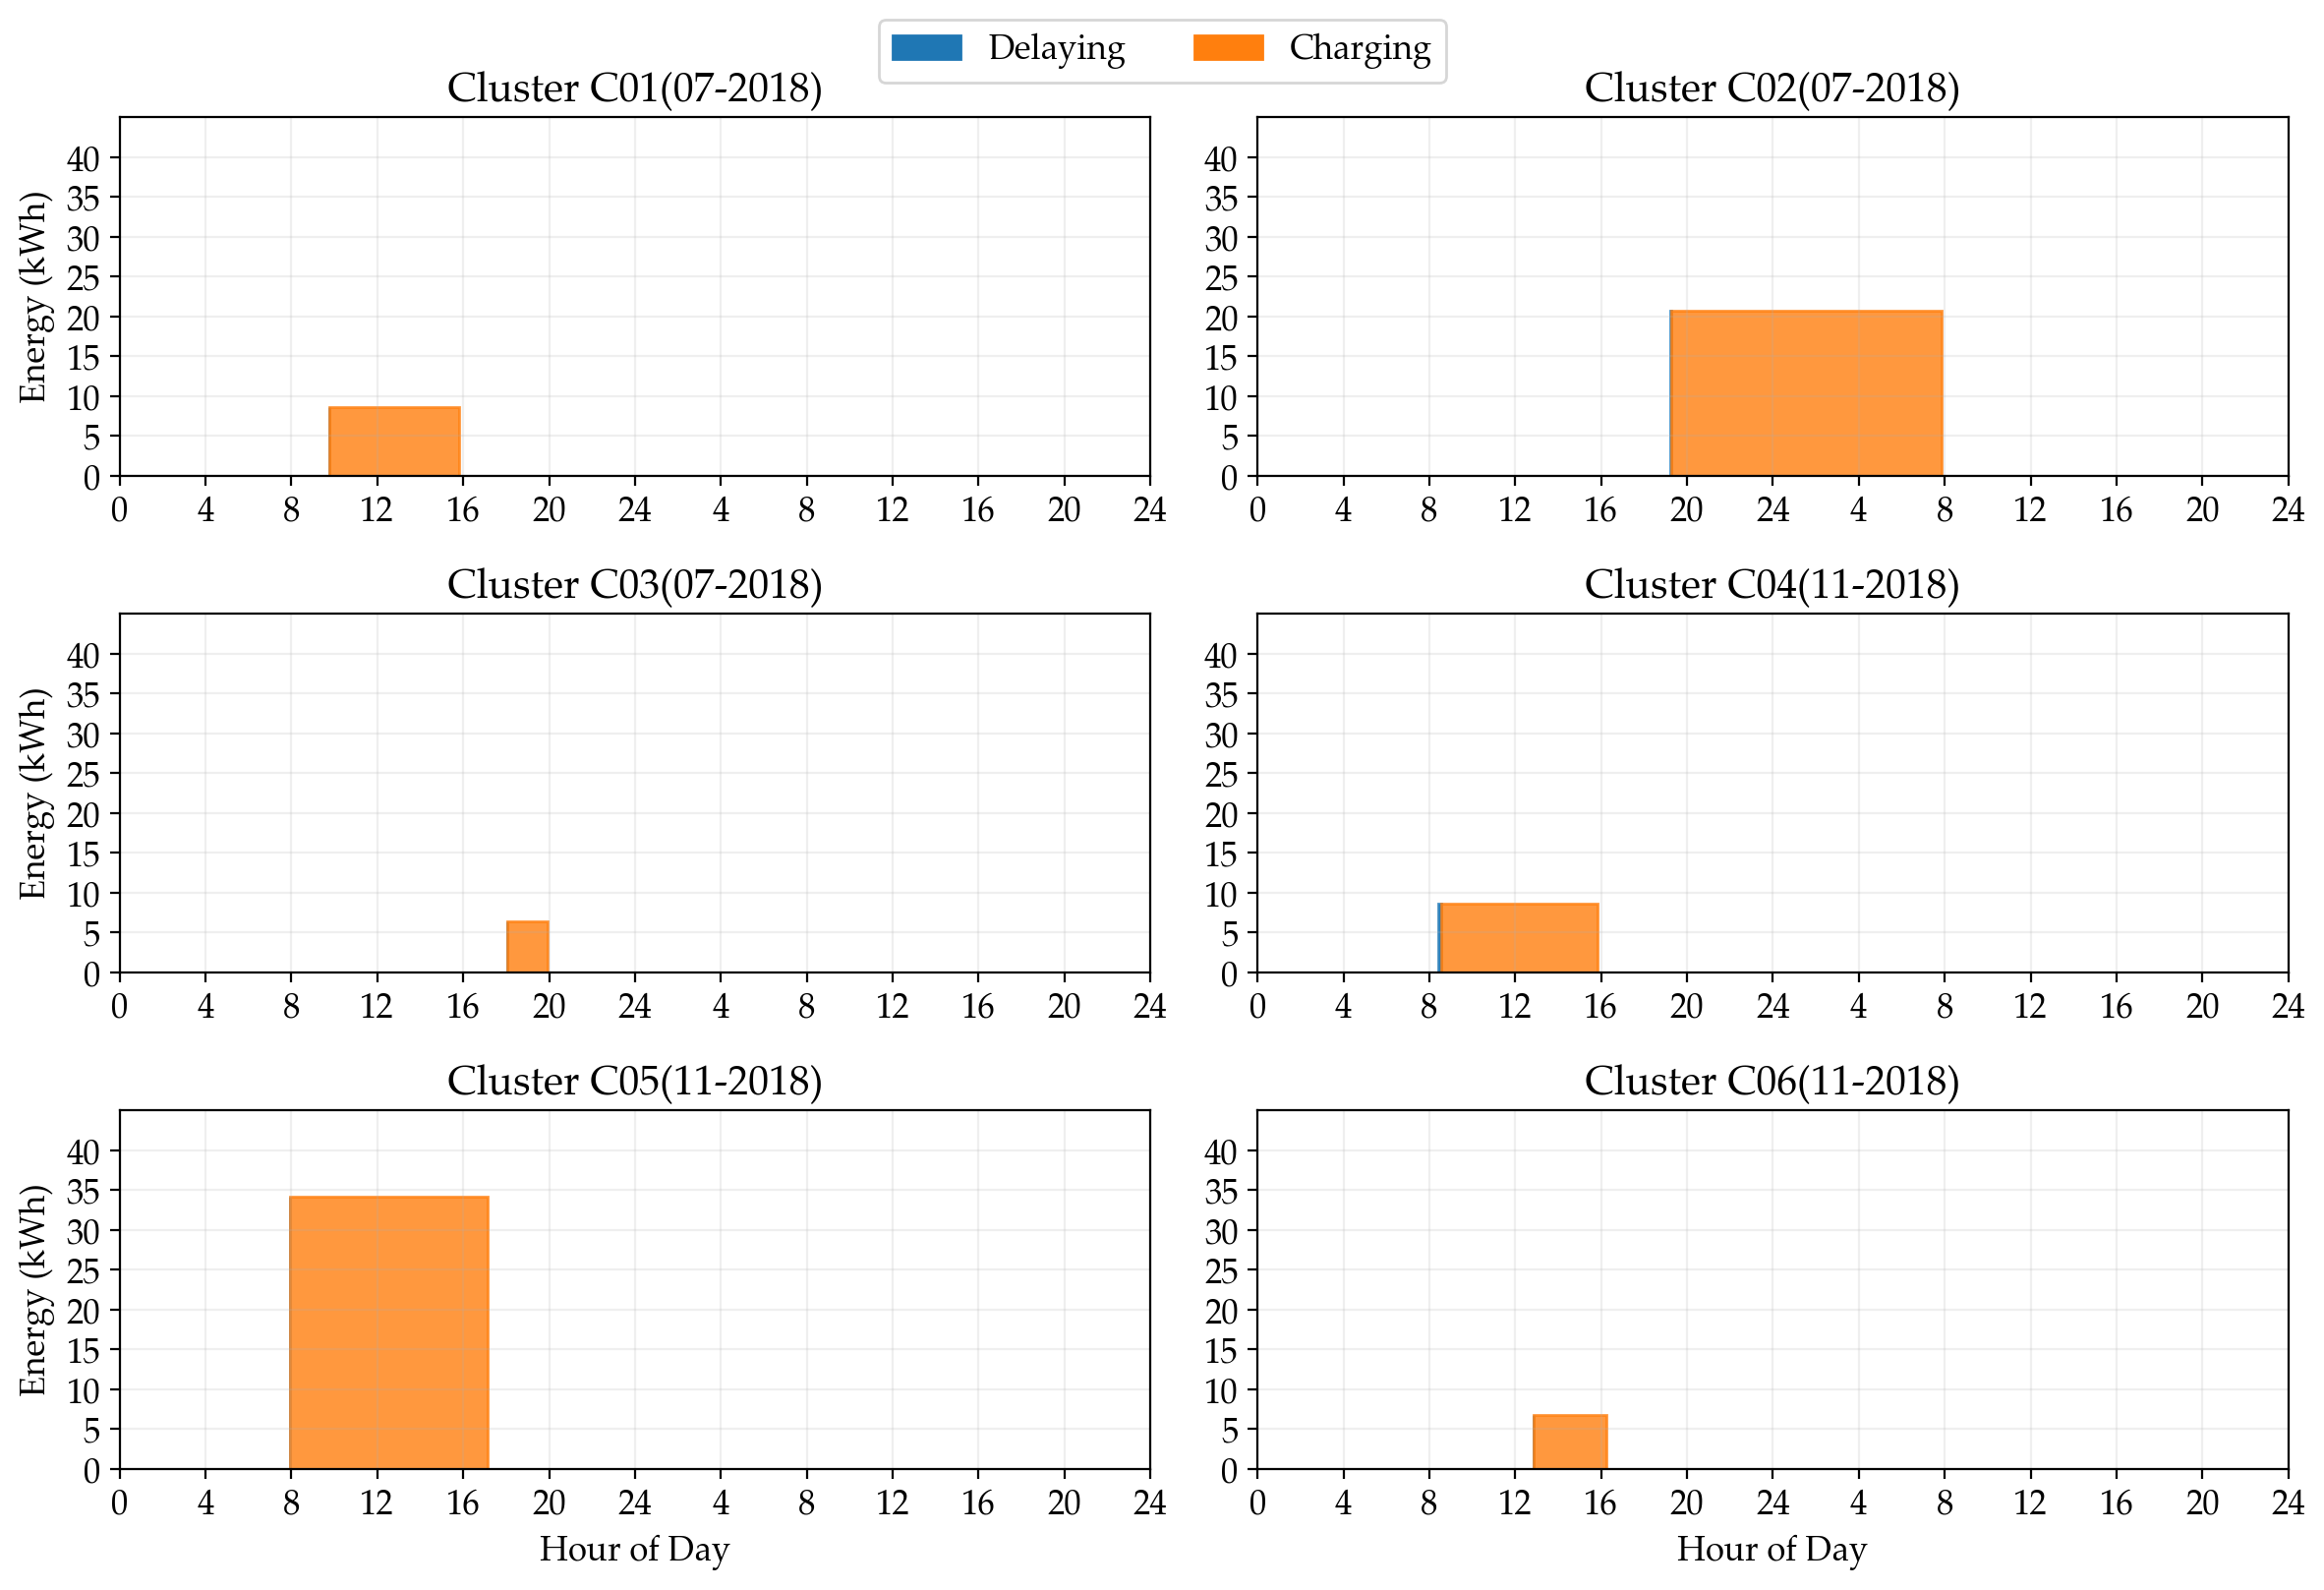

In [17]:
cluster_objects_pool = apply_new_names(cluster_objects_pool, old_new_tags)
cluster_objects_pool = apply_new_names(cluster_objects_pool, key_old_new)
subset_dict = dict(list(cluster_objects_pool.items())[0:8])

features = ['plugin_duration', 'plugin_hour_sine', 'plugin_hour_cosine', 'energy', 'delay']
df_ct = plot_clusters_delay(subset_dict, scaler, features)

In [ ]:
cluster_names = [
     'C01(07-2018)',

]

cluster_weights = {
     'C01(07-2018)': 1,

}
load_profile, delay_profile, df_joint = plot_average_load_and_delay_separate(
    kdes=cluster_objects_pool,
    cluster_names=cluster_names,
    scaler=state["scaler"],
    cluster_weights=cluster_weights,
    n_samples_per_cluster=5000,
    random_state=42,
    kwh_per_hour=11,

)